In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [4]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [5]:
df.drop(columns=["Cabin"], inplace=True)

In [6]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [7]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [8]:
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True,
    dtype=int
)

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
FamilySize     0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [10]:
df.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

Every supervised machine learning problem has two parts:

* Input (Features) → X
* Output (Target/Label) → y

Take the DataFrame and drop the Survived column. Everything else becomes X.

In [11]:
X = df.drop(columns = ["Survived"])

Take only the Survived column. This is what the model must learn to predict.

In [12]:
y = df["Survived"]

In [13]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,2,0,1
1,1,1,38.0,1,0,71.2833,2,0,0
2,3,1,26.0,0,0,7.9250,1,0,1
3,1,1,35.0,1,0,53.1000,2,0,1
4,3,0,35.0,0,0,8.0500,1,0,1


891 Passengers

      │

      ▼

Training Set (80%)

Model learns from this

      │

      ▼

Testing Set (20%)

Model has NEVER seen these passengers.

Passenger A’s features must always stay with Passenger A’s label.

The library never shuffles X and y separately.

It shuffles the rows together.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

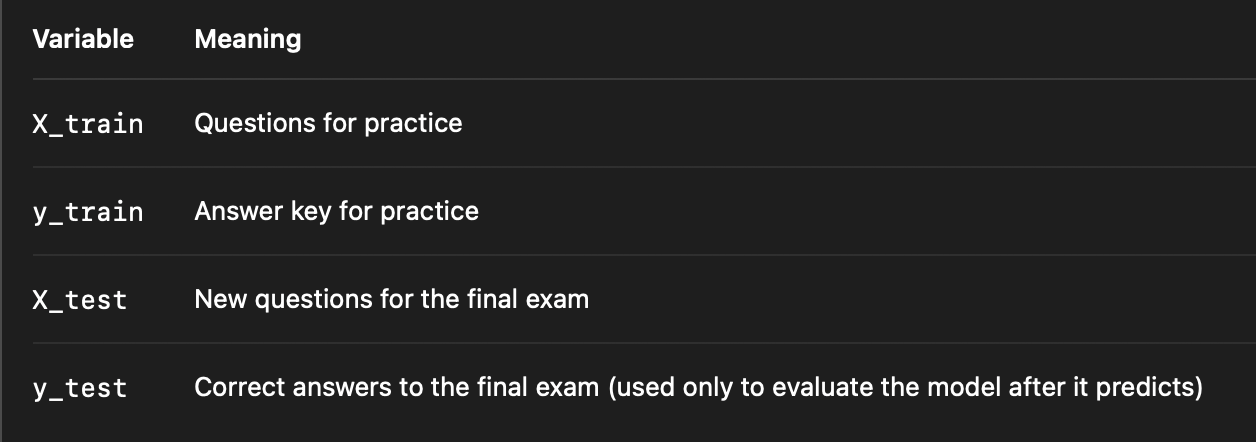

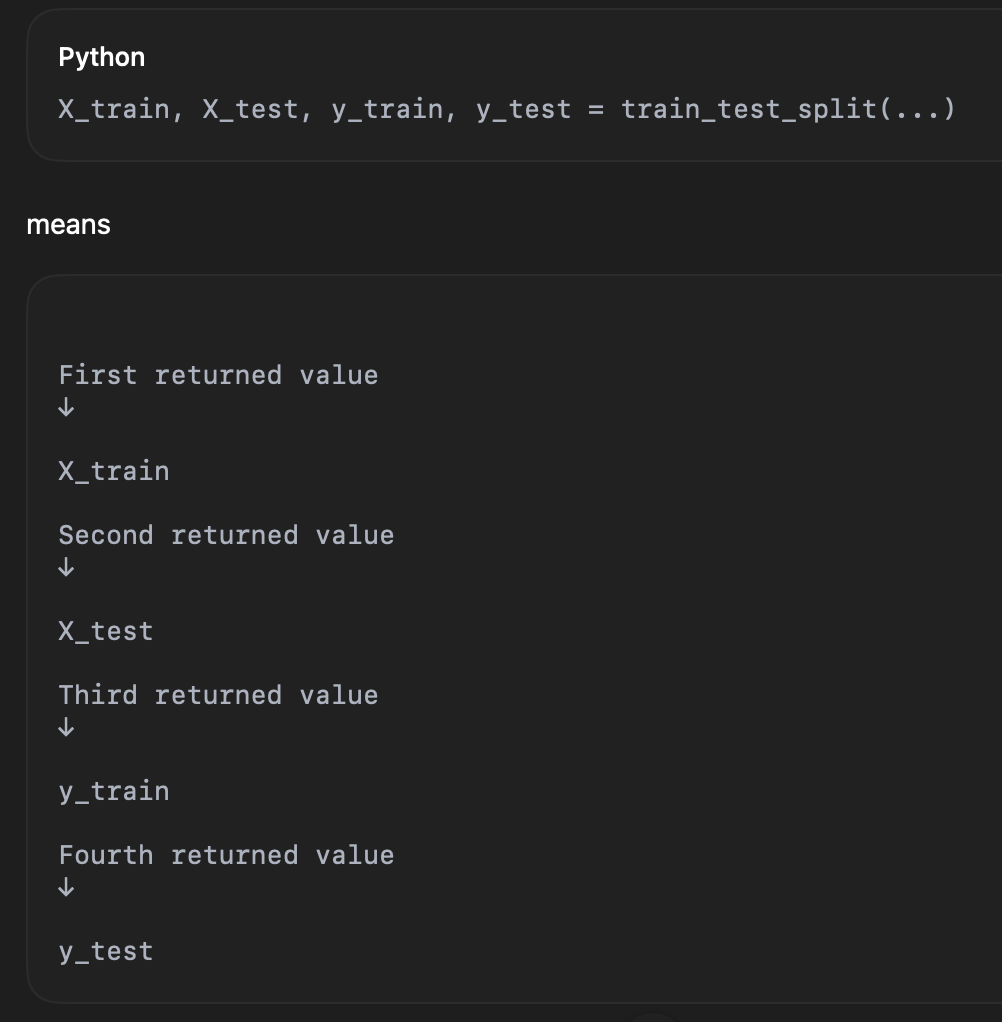

In [15]:
model = LogisticRegression()

In [16]:
model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [17]:
y_pred = model.predict(X_test)

In [18]:
print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [19]:
y_test[:10]

709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
Name: Survived, dtype: int64

### ACCURACY SCORE


In [20]:
from sklearn.metrics import accuracy_score

In [21]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7988826815642458


### CONFUSION MATRIX

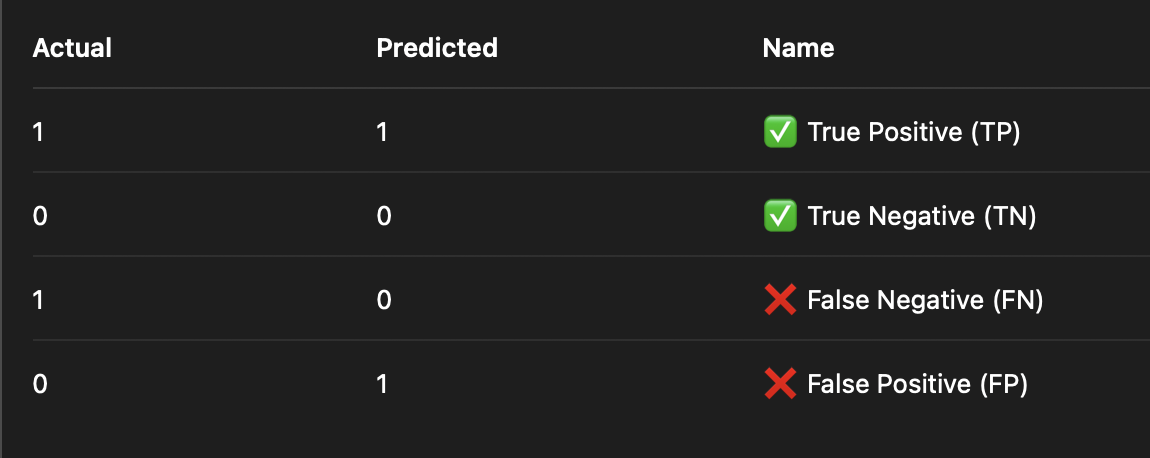

In [22]:
from sklearn.metrics import confusion_matrix

In [23]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[89 16]
 [20 54]]


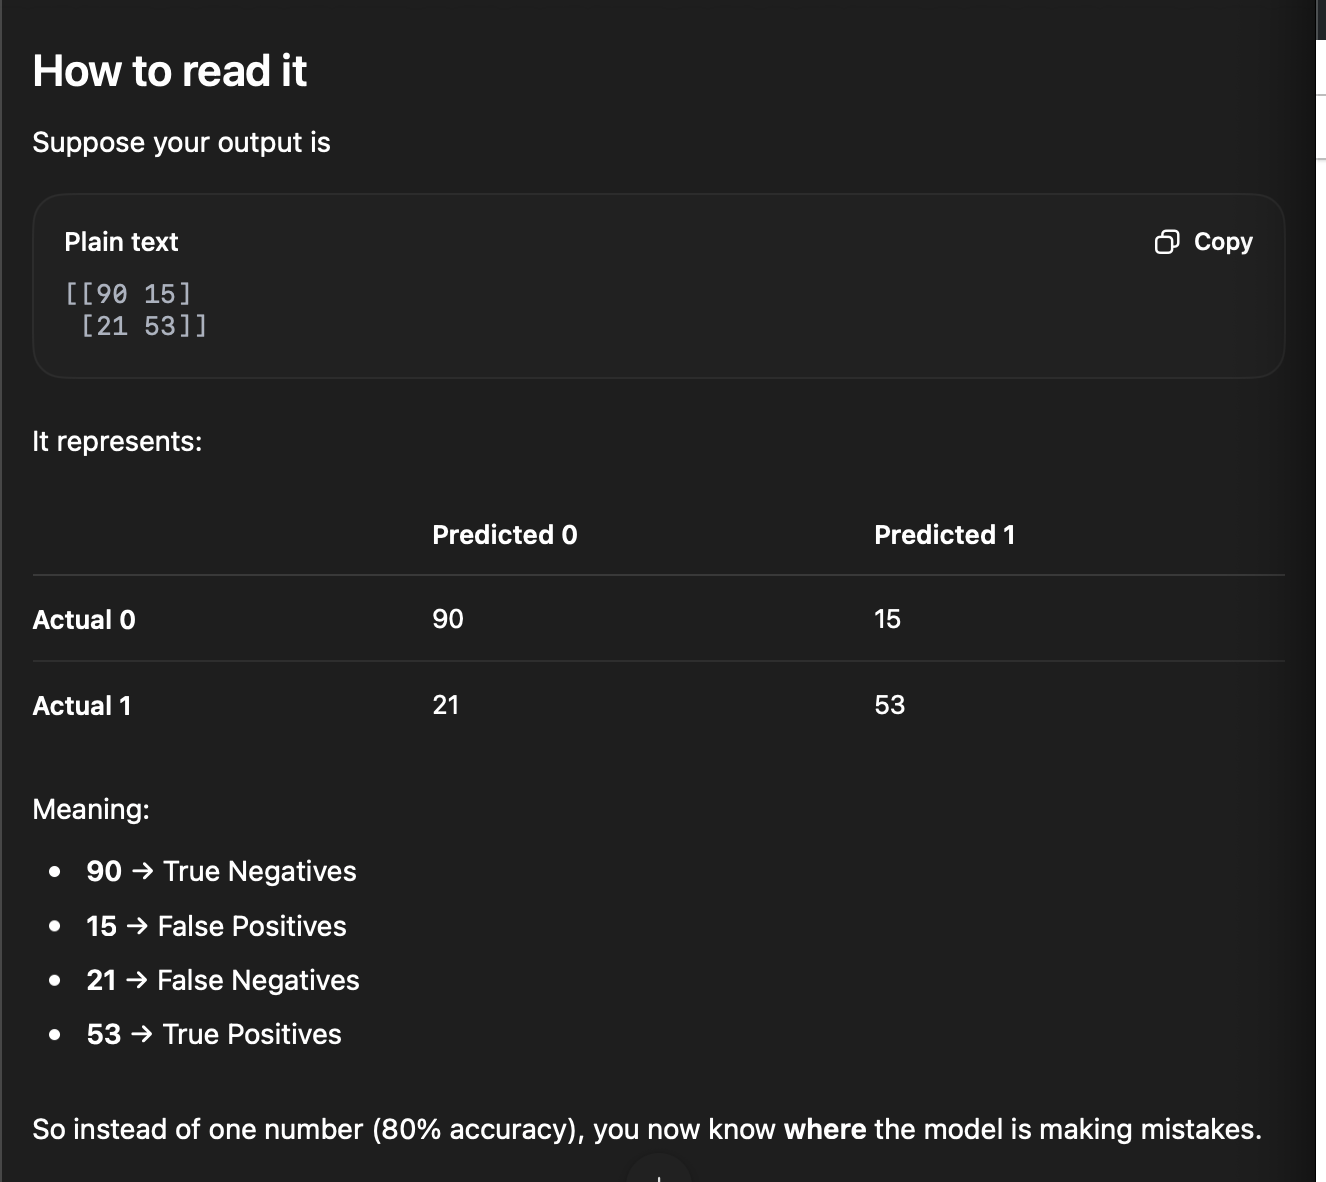

In [24]:
from sklearn.metrics import classification_report 

In [25]:
cr = classification_report(y_test,y_pred)

In [26]:
print(cr)

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### MODEL COEFFICIENTS

- Model coefficients are the values learned by a machine learning model during training that determine how much each input feature influences the prediction.
- A positive coefficient increases the prediction score, while a negative coefficient decreases it.
  

In [27]:
print(model.coef_)

[[-0.9230632   2.57791197 -0.03054812 -0.62709102 -0.43257632  0.00278384
   0.32642219 -0.03585016 -0.37698533]]


print(X.columns)

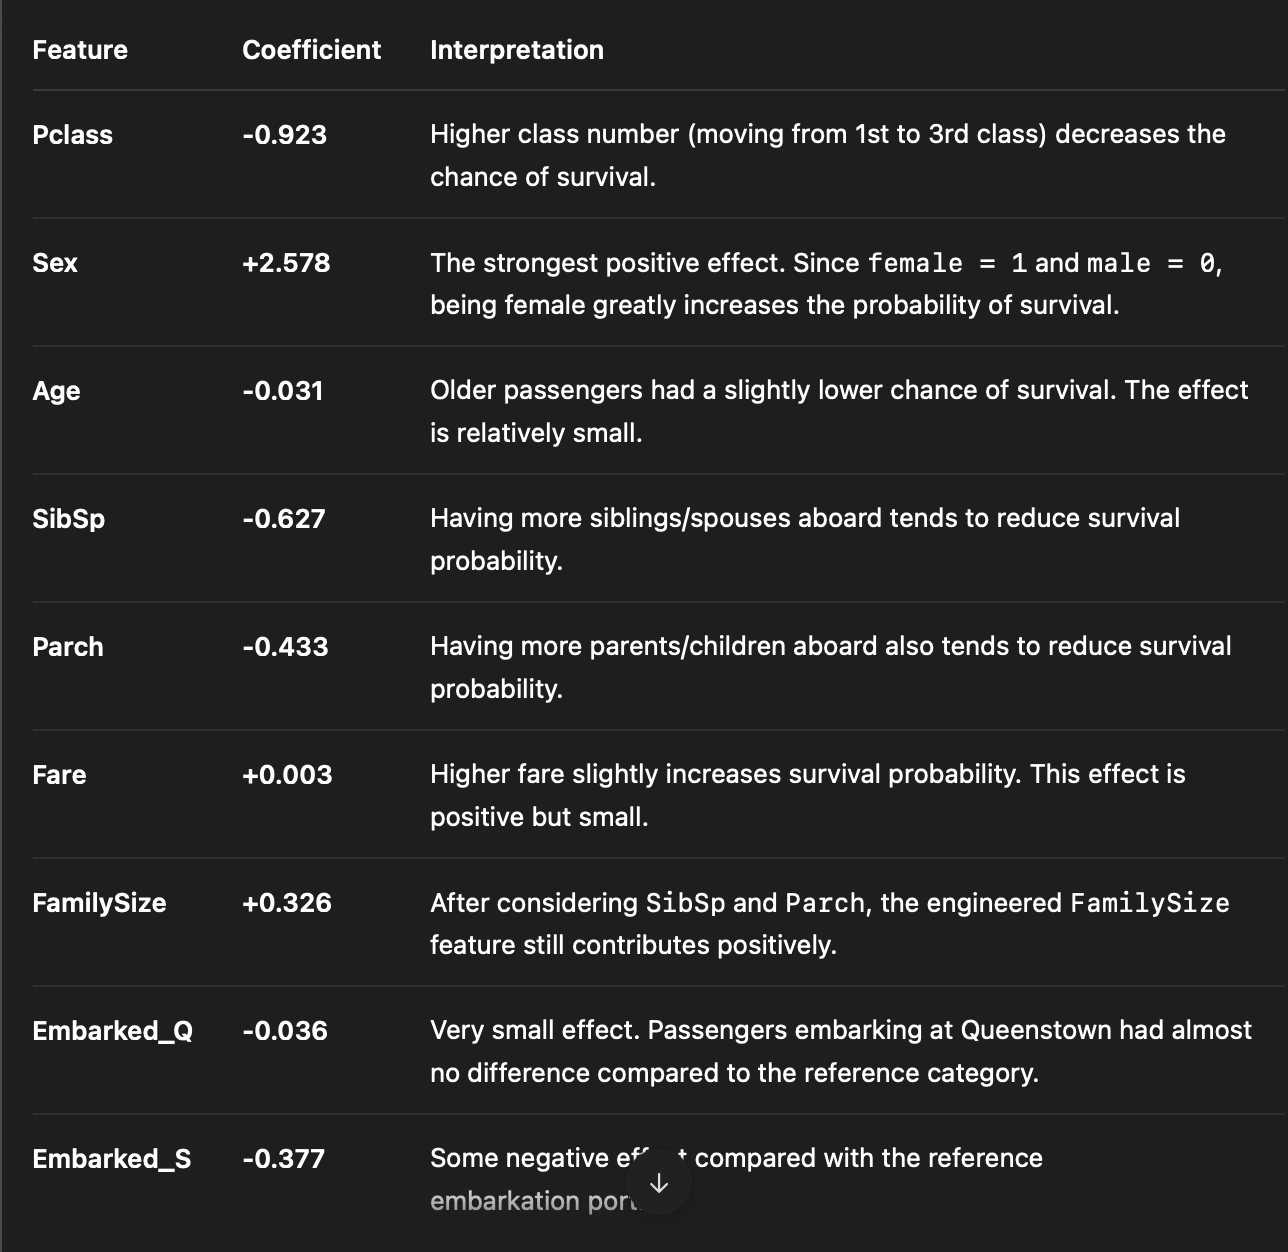

### MODEL INTERCEPTS

The model intercept is the initial prediction score learned during training before the effect of any input features is added. It acts as the model’s starting point for making predictions.

In [28]:
print(model.intercept_)

[1.56906738]


### StandardScaler

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

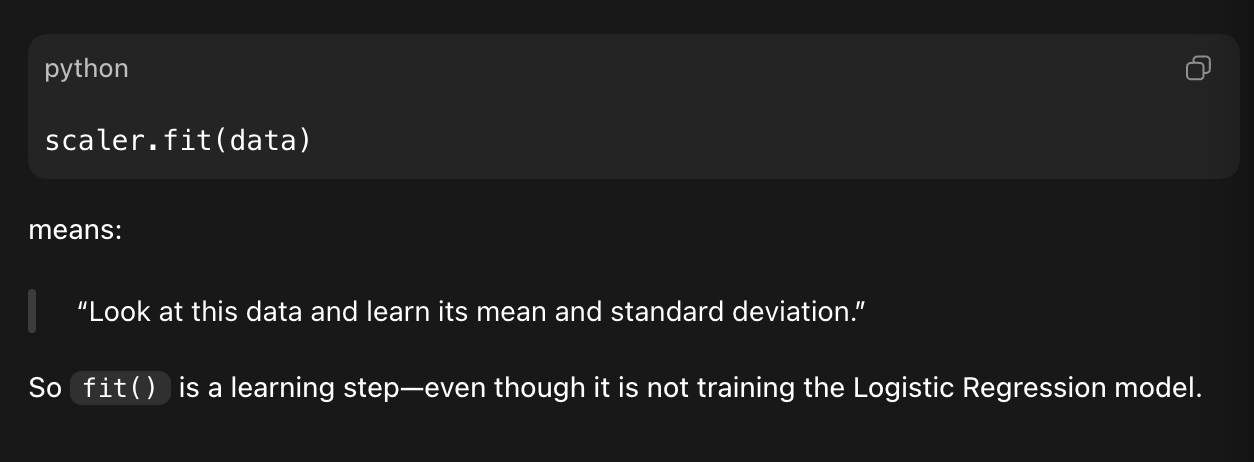

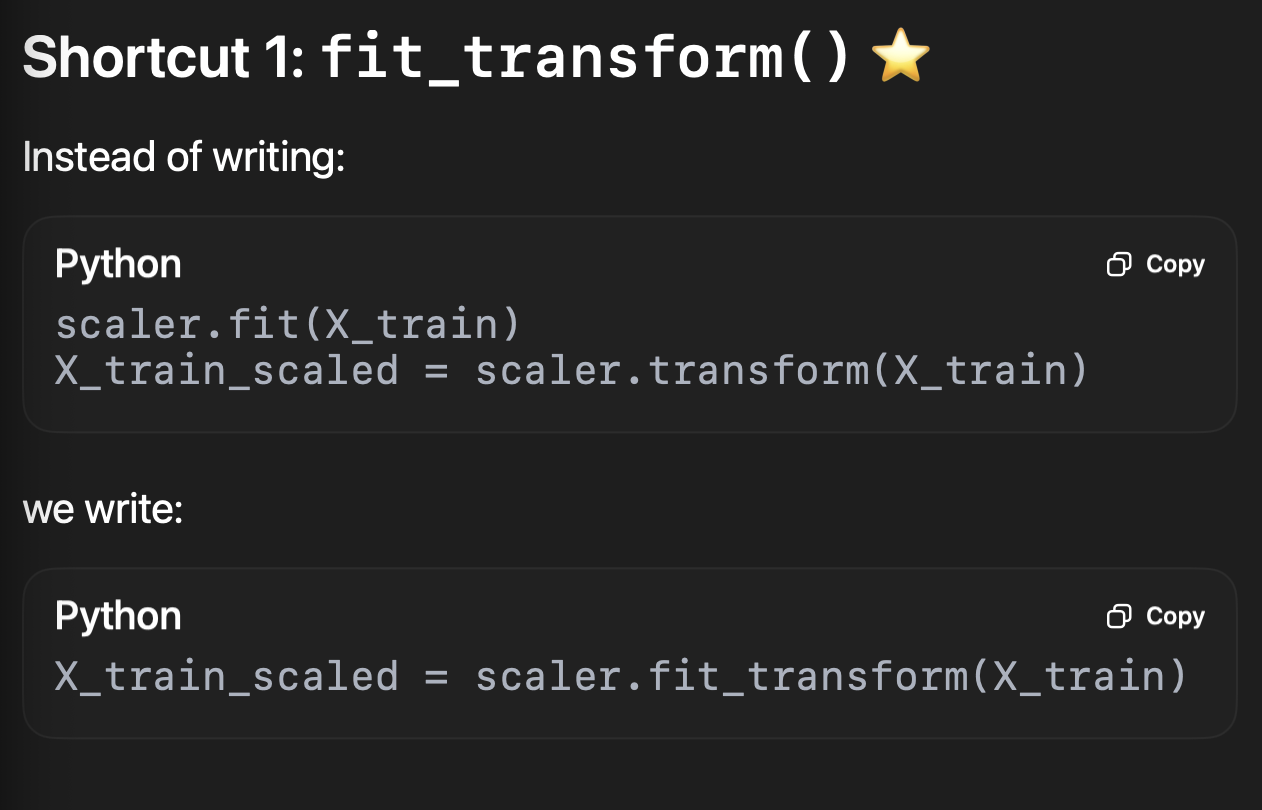
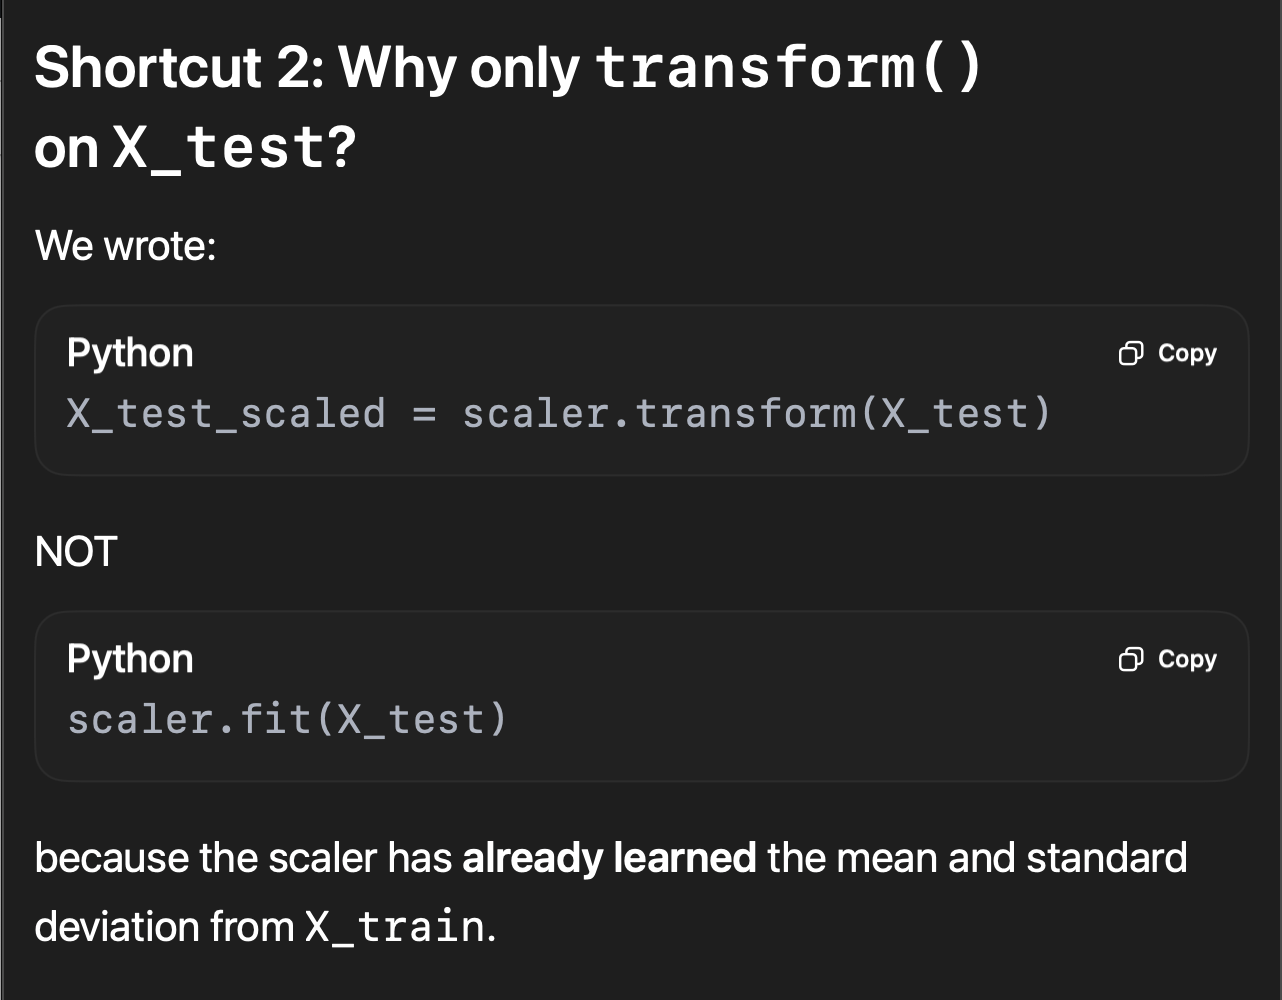



In [30]:
model_scaled = LogisticRegression()

model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("Accuracy:", accuracy_scaled)

Accuracy: 0.8100558659217877


### Cross Validation

- Cross Validation is a model evaluation technique in which the training dataset is divided into multiple folds.
- The model is trained and validated multiple times, using a different fold as the validation set in each iteration.
- The final performance is measured by averaging the results from all folds, providing a more reliable estimate of the model’s performance on unseen data.

In [31]:
from sklearn.model_selection import cross_val_score

In [32]:
scores = cross_val_score(
    model_scaled,
    X_train_scaled,
    y_train,
    cv= 5
)

In [33]:
print(scores)

[0.82517483 0.8041958  0.78873239 0.73943662 0.79577465]


print(scores.mean())

In [34]:
print("CV scores:", scores)
print("Mean accuracy:", scores.mean())
print("Standard deviation:", scores.std())


CV scores: [0.82517483 0.8041958  0.78873239 0.73943662 0.79577465]
Mean accuracy: 0.7906628582684921
Standard deviation: 0.028383802018759997


### Data Leakage
- Data leakage occurs when information from the validation or test data is accidentally used during training, leading to an unrealistically high model performance.
- In our Titanic project, data leakage would occur if StandardScaler learned the mean and standard deviation from the entire X_train before cross-validation. This would allow the temporary validation fold to influence preprocessing before evaluation. We prevent this by using a Pipeline, which fits the scaler separately within each training fold.

### Pipeline

A Pipeline is a Scikit-learn utility that combines multiple preprocessing and machine learning steps into a single workflow, ensuring they are executed in the correct order automatically.

In [35]:
from sklearn.pipeline import Pipeline

In [36]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# GridSearchCV

## Definition

GridSearchCV is a Scikit-learn tool that automatically finds the best hyperparameter values using Cross Validation.

---

# Why do we use GridSearchCV?

Instead of manually trying different values of a hyperparameter, GridSearchCV tests all the given values and selects the one with the best performance.

---

# Hyperparameter

A hyperparameter is a value chosen **before** training that controls how the model learns.

Example:

- C
- max_iter
- solver

---

# Parameter

A parameter is a value learned automatically by the model during training.

Example:

- model.coef_
- model.intercept_

---

# What is C?

`C` is a hyperparameter of Logistic Regression.

It controls how closely the model fits the training data.

- Small C → Simpler model (more regularization)
- Large C → More flexible model (less regularization)

---

# Parameter Grid

```python
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}
```

**Meaning:**

We are asking GridSearchCV to test the Logistic Regression model using five different values of `C`.

---

# Meaning of the values

- `0.01` → Very simple model
- `0.1` → Simple model
- `1` → Default balanced model
- `10` → More flexible model
- `100` → Very flexible model

GridSearchCV compares all of them and chooses the best one.

---


In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 500, 1000]
}
# GridSearchCV test these five values of C and tells which one works best.

In [39]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5
)

### What is an Estimator?

## Definition

- An estimator is any Scikit-learn object that can learn from data using fit().

- In simple words:

- An estimator is an object that can be trained on data.

In [40]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__max_iter': [100, 500, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of info

In [41]:
grid.best_params_
grid.best_score_
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Pclass','Sex','Age',...,'FamilySize','Embarked_Q','Embarked_S']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


What is best_estimator_?



grid.best_estimator_ returns the complete trained Pipeline with the best hyperparameter values found by GridSearchCV.

In [42]:
best_model = grid.best_estimator_

In [43]:
y_pred = best_model.predict(X_test)

In [44]:
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

**GridSearchCV does not directly modify the original Pipeline. It creates multiple Pipeline models with different hyperparameter values, evaluates them using Cross Validation, and returns the best-performing Pipeline as grid.best_estimator_.**

In [45]:
accuracy_score(y_test, y_pred)

0.7932960893854749

In [46]:
print(grid.best_params_)
print(grid.best_score_)

{'model__C': 0.01, 'model__max_iter': 100}
0.8005318625036935


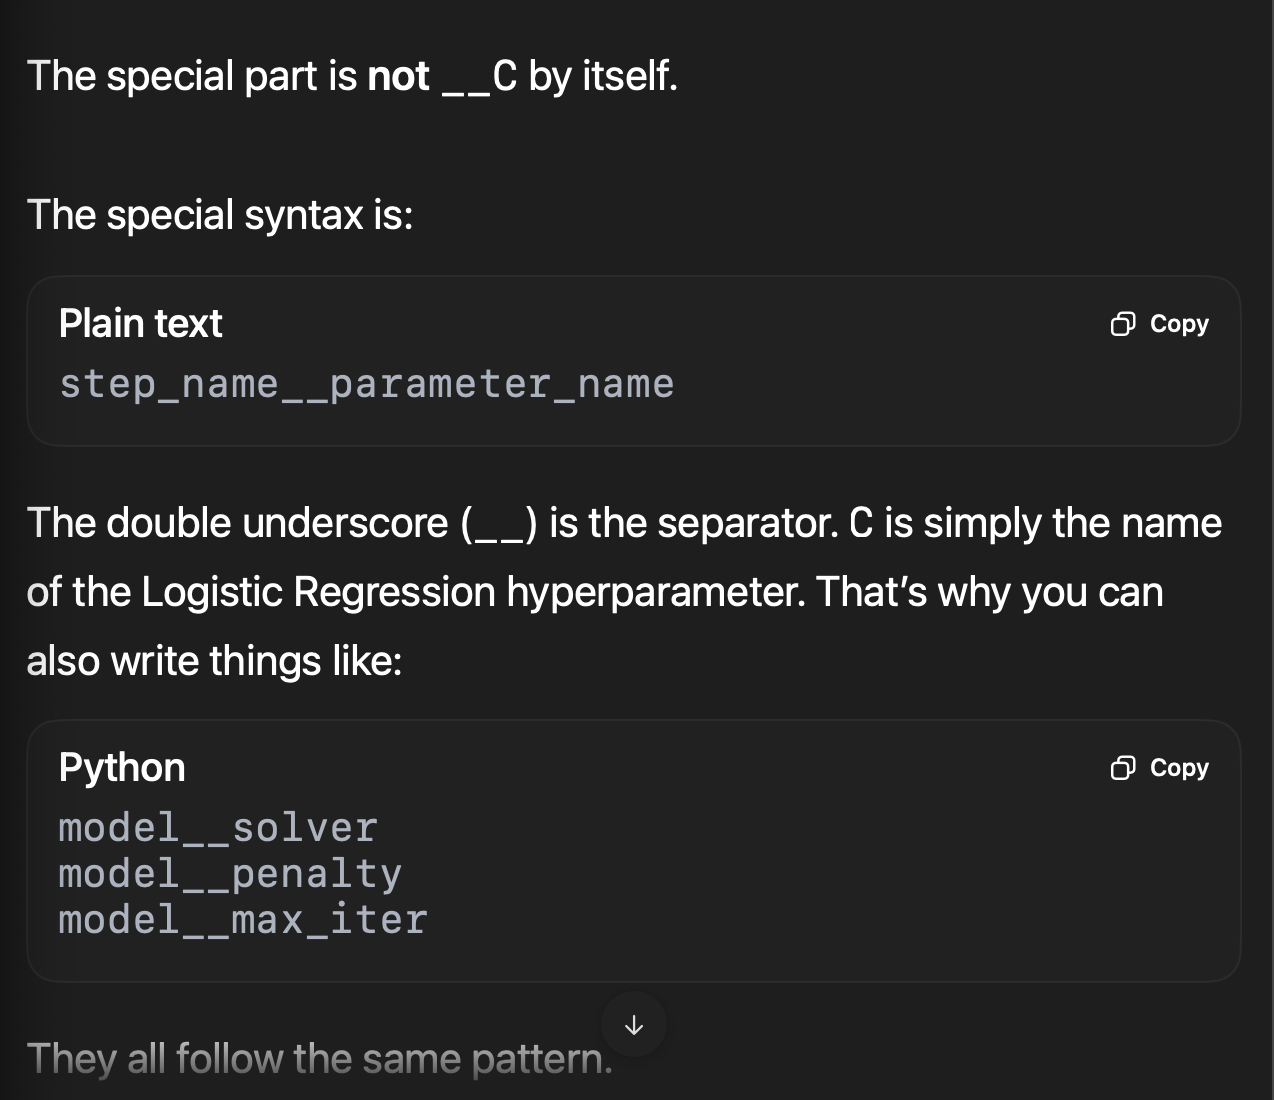

In [47]:
import joblib

In [48]:
best_model = grid.best_estimator_

In [49]:
joblib.dump(best_model, "titanic_model.pkl")

['titanic_model.pkl']

In [52]:
model = joblib.load("titanic_model.pkl")

In [53]:
type(model)

sklearn.pipeline.Pipeline

In [54]:
new_passenger = pd.DataFrame({

    "Pclass": [1],

    "Sex": [1],

    "Age": [25],

    "SibSp": [0],

    "Parch": [0],

    "Fare": [100],

    "FamilySize": [1],

    "Embarked_Q": [0],

    "Embarked_S": [1]

})

In [56]:
prediction = model.predict(new_passenger)

print(prediction)

[1]


In [58]:
model.predict_proba(new_passenger)

array([[0.2326921, 0.7673079]])